In [1]:
#undef __noinline__

Work in progress. Doenst show picure.

In [2]:
#define DIM 1024
#include <math.h>

__global__ void kernel( unsigned char *ptr, int ticks ) {
    int x = threadIdx.x + blockIdx.x * blockDim.x;
    int y = threadIdx.y + blockIdx.y * blockDim.y;
    
    // Use DIM for the stride to ensure perfect RGBA alignment
    int offset = x + y * DIM;

    if (x < DIM && y < DIM) {
        float fx = x - DIM/2.0f;
        float fy = y - DIM/2.0f;
        float d = sqrtf( fx * fx + fy * fy );

        // Use cosf and ensure floating point constants (1.0f)
        float ripple = cosf(d/10.0f - ticks/7.0f) / (d/10.0f + 1.0f);
        unsigned char grey = (unsigned char)(128.0f + 127.0f * ripple);

        ptr[offset*4 + 0] = grey;
        ptr[offset*4 + 1] = grey;
        ptr[offset*4 + 2] = grey;
        ptr[offset*4 + 3] = 255; // Alpha MUST be 255
    }
}

In [3]:
#include "assets/cpu_anim.h"

struct DataBlock {
    unsigned char *dev_bitmap;
    CPUAnimBitmap *bitmap;
};
// clean up memory allocated on the GPU
void cleanup( DataBlock *d ) {
    cudaFree( d->dev_bitmap );
}

void generate_frame( DataBlock *d, int ticks ) {
    dim3 blocks(DIM/16, DIM/16);
    dim3 threads(16, 16);
    
    kernel<<<blocks, threads>>>( d->dev_bitmap, ticks );
    
    // Crucial: Wait for GPU to finish before copying!
    cudaDeviceSynchronize();

    // Corrected Memcpy call
    cudaMemcpy( d->bitmap->get_ptr(), 
                d->dev_bitmap, 
                d->bitmap->image_size(), 
                cudaMemcpyDeviceToHost );
}

In [4]:
#define STB_IMAGE_WRITE_IMPLEMENTATION
#include "assets/stb_image_write.h"

DataBlock data;
 CPUAnimBitmap bitmap( DIM, DIM, &data );
 data.bitmap = &bitmap;

cudaMalloc( (void**)&data.dev_bitmap, bitmap.image_size() );

// 1. Run the generation function manually
generate_frame(&data, 0); 

// 2. Save the result to a file (since we have no window)
stbi_write_png("assets/ripple.png", DIM, DIM, 4, bitmap.get_ptr(), DIM * 4);

// 3. Run the cleanup function manually
cleanup(&data);

In [5]:
#include <string>
#include <fstream>
#include <sstream>

#include "nlohmann/json.hpp"

#include "xeus/xbase64.hpp"

namespace nl = nlohmann;

namespace im
{
    struct image
    {   
        inline image(const std::string& filename)
        {
            std::ifstream fin(filename, std::ios::binary);   
            m_buffer << fin.rdbuf();
        }
        
        std::stringstream m_buffer;
    };
    
    nl::json mime_bundle_repr(const image& i)
    {
        auto bundle = nl::json::object();
        bundle["image/png"] = xeus::base64encode(i.m_buffer.str());
        return bundle;
    }
}

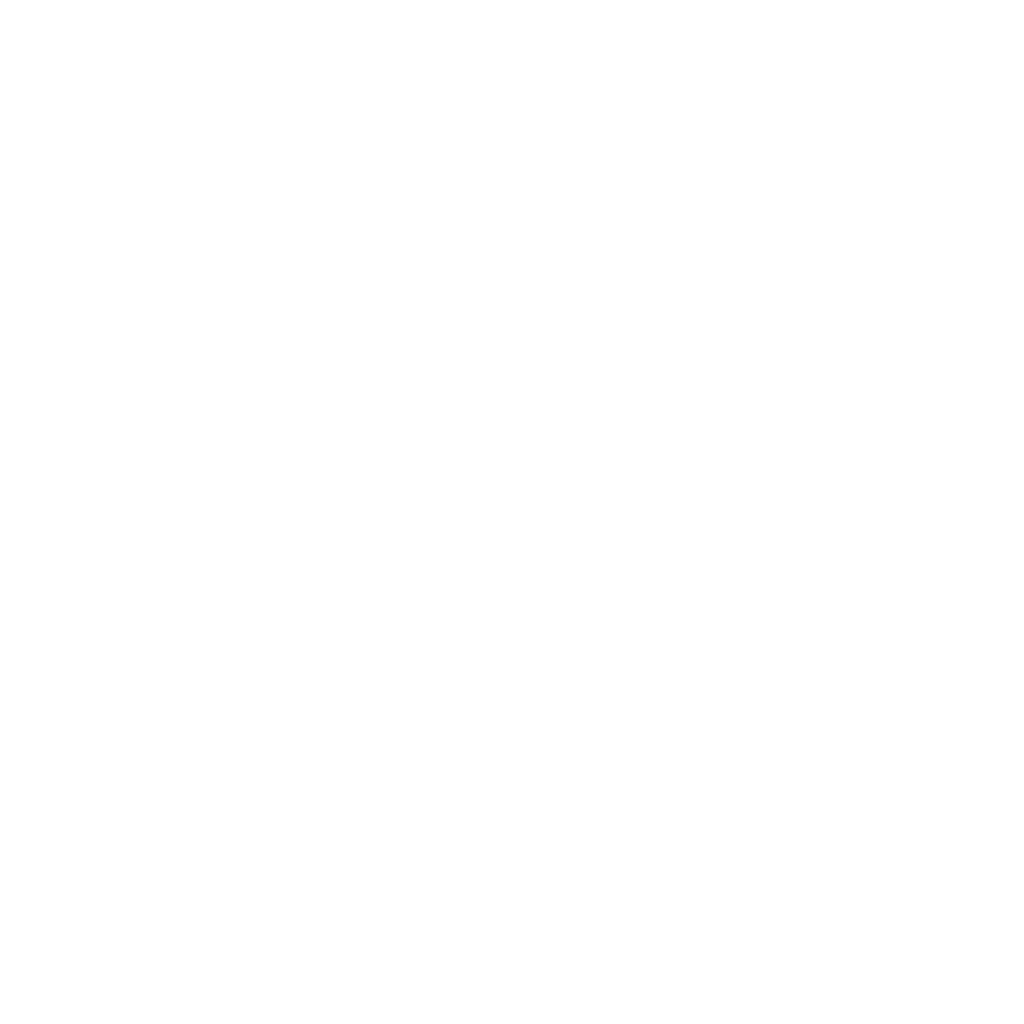

In [6]:
#include "xcpp/xdisplay.hpp"

im::image julia_image("assets/ripple.png");
xcpp::display(julia_image);